# Getting Started with chironpy

This notebook demonstrates the core chironpy APIs using the bundled example data.

Run it from the project root after `poetry install` (or `make install`).

In [1]:
import chironpy

## Load a bundled example activity

`chironpy.examples()` returns metadata about the bundled example files in `chironpy/examples/data/`.

Use `path=` to select a specific file, or `sport=` / `file_type=` to filter.

In [2]:
# Load a cycling FIT file with power, heartrate, cadence, elevation
example = chironpy.examples(path="4078723797.fit")
print(example.path)
print("sport:", example.sport, "| file_type:", example.file_type)

/Users/clive/projects/chironpy/chironpy/examples/data/4078723797.fit
sport: SportEnum.cycling | file_type: FileTypeEnum.fit


In [3]:
# Read the file into a DataFrame — resample to 1s and interpolate gaps
data = chironpy.read_file(example.path, resample=True, interpolate=True)
print(data.shape)
data.head()

(8357, 25)


,latitude,longitude,distance,accumulated_power,enhanced_altitude,elevation,enhanced_speed,speed,power,unknown_61,...,record_sequence,left-right balance,left_torque_effectiveness,right_torque_effectiveness,left_pedal_smoothness,right_pedal_smoothness,right balance,left balance,session,lap
datetime,,,,,,,,,,,,,,,,,,,,,
2019-09-20 14:10:03+00:00,50.392568,5.900304,0.01,0.0,473.8,473.8,0.000,0.000,0.0,4869.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2019-09-20 14:10:04+00:00,50.392568,5.900305,0.09,0.0,473.6,473.6,0.000,0.000,0.0,4863.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2019-09-20 14:10:05+00:00,50.392569,5.900306,0.17,0.0,474.0,474.0,0.000,0.000,0.0,4862.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2019-09-20 14:10:06+00:00,50.392569,5.900306,0.23,0.0,473.8,473.8,0.000,0.000,0.0,4860.0,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2019-09-20 14:10:07+00:00,50.392570,5.900307,0.31,0.0,473.6,473.6,0.504,0.504,0.0,4859.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


## Explore the data

In [4]:
print(data.columns.tolist())
data.describe()

['latitude', 'longitude', 'distance', 'accumulated_power', 'enhanced_altitude', 'elevation', 'enhanced_speed', 'speed', 'power', 'unknown_61', 'unknown_66', 'heartrate', 'cadence', 'temperature', 'fractional_cadence', 'record_sequence', 'left-right balance', 'left_torque_effectiveness', 'right_torque_effectiveness', 'left_pedal_smoothness', 'right_pedal_smoothness', 'right balance', 'left balance', 'session', 'lap']


,latitude,longitude,distance,accumulated_power,enhanced_altitude,elevation,enhanced_speed,speed,power,unknown_61,...,record_sequence,left-right balance,left_torque_effectiveness,right_torque_effectiveness,left_pedal_smoothness,right_pedal_smoothness,right balance,left balance,session,lap
count,8357.000000,8357.000000,8357.000000,8.357000e+03,8357.000000,8357.000000,8357.000000,8357.000000,8357.000000,8357.000000,...,8357.000000,8345.000000,8345.0,8345.0,8345.000000,8345.000000,8345.000000,8345.000000,8357.0,8357.0
mean,50.434083,5.870275,30951.194010,9.407418e+05,396.854541,396.854541,6.748600,6.748600,219.070599,4389.618882,...,4178.000000,179.421090,0.0,0.0,42.898682,42.898682,51.421090,48.578910,0.0,0.0
std,0.027382,0.040232,17056.874762,5.516739e+05,91.176471,91.176471,3.850749,3.850749,130.009102,442.824394,...,2412.602433,9.034157,0.0,0.0,17.105667,17.105667,9.034157,9.034157,0.0,0.0
min,50.383502,5.791599,0.010000,0.000000e+00,229.000000,229.000000,0.000000,0.000000,0.000000,3567.000000,...,0.000000,131.000000,0.0,0.0,0.000000,0.000000,3.000000,0.000000,0.0,0.0
25%,50.412369,5.839935,14478.350000,5.230640e+05,326.200000,326.200000,4.078000,4.078000,141.000000,4032.000000,...,2089.000000,178.000000,0.0,0.0,42.500000,42.500000,50.000000,46.000000,0.0,0.0
50%,50.435973,5.873329,29733.840000,9.687060e+05,400.800000,400.800000,5.496000,5.496000,259.000000,4398.000000,...,4178.000000,181.000000,0.0,0.0,49.000000,49.000000,53.000000,47.000000,0.0,0.0
75%,50.448162,5.900352,46807.820000,1.407279e+06,476.800000,476.800000,9.088000,9.088000,305.000000,4779.000000,...,6267.000000,182.000000,0.0,0.0,53.500000,53.500000,54.000000,50.000000,0.0,0.0
max,50.492351,5.934672,57567.240000,1.830776e+06,568.000000,568.000000,19.389000,19.389000,1022.000000,5272.000000,...,8356.000000,228.000000,0.0,0.0,73.000000,73.000000,100.000000,97.000000,0.0,0.0


## Mean-max (power duration curve)

The `.chironpy` accessor is registered on pandas Series and DataFrames.

In [5]:
mmp = data["power"].chironpy.mean_max()
mmp.head(10)

0 days 00:00:01    1022.000000
0 days 00:00:02     980.500000
0 days 00:00:03     928.666667
0 days 00:00:04     847.750000
0 days 00:00:05     721.600000
0 days 00:00:06     663.666667
0 days 00:00:07     622.714286
0 days 00:00:08     591.875000
0 days 00:00:09     554.888889
0 days 00:00:10     517.400000
Name: mean_max_power, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Mean Max Power (W)'}, xlabel='Duration (s)', ylabel='Power (W)'>

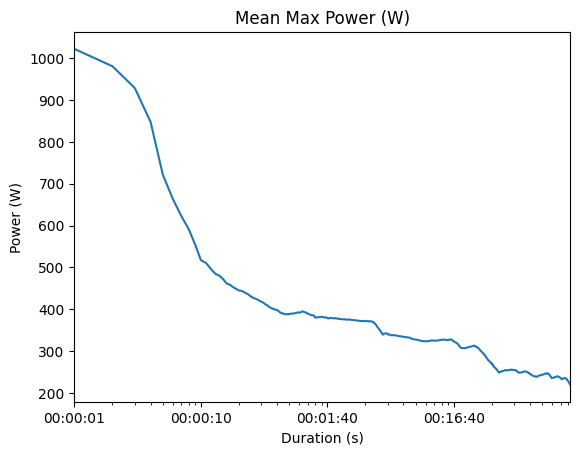

In [6]:
mmp.plot(logx=True, title="Mean Max Power (W)", xlabel="Duration (s)", ylabel="Power (W)")

## Best interval

Find the best (highest average power) interval of a given duration (seconds).

In [7]:
from chironpy.metrics.core import best_interval

best_20min = best_interval(data["power"], window=1200)
print("Best 20-min power:", best_20min)

Best 20-min power: {'value': 306.815, 'start_index': 474, 'stop_index': 1674}


## Elevation gain

In [8]:
from chironpy.metrics.vert import elevation_gain

gain = elevation_gain(data["elevation"])
print(f"Total elevation gain: {gain:.0f} m")

Total elevation gain: 1341 m


## WorkoutData model

The higher-level `WorkoutData` model wraps the DataFrame and exposes metric methods directly.

In [9]:
workout = chironpy.WorkoutData.from_file(example.path, resample=True, interpolate=True)
print(type(workout))
print(workout.elevation_gain())

<class 'chironpy.models.workout.WorkoutData'>
1341.3999999999992


## Load your own files

Drop `.fit`, `.tcx`, `.gpx`, or Strava JSON files into `lab/data/` and load them here.

`read_file` auto-detects the format from the file extension.

In [10]:
# my_data = chironpy.read_file("lab/data/my_activity.fit", resample=True, interpolate=True)
# my_data.head()